In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")

In [15]:
df = pd.read_csv(
    "/content/processed_fraud_dataset.csv"
)

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,AverageItemPrice,Risk_Flag
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1,570.62,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8,151.35,0
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2,550.68,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10,273.19,0
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5,626.01,1


In [16]:
df.shape

(1200, 18)

In [17]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Year',
       'Month', 'AverageItemPrice', 'Risk_Flag'],
      dtype='object')

In [18]:
df_model = df.drop(
    [
        "OrderID",
        "CustomerID",
        "Date",
        "ShippingAddress",
        "TrackingNumber",
        "CouponCode",
        "Product"
    ],
    axis=1
)


df_model.head()

,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,ReferralSource,TotalPrice,Year,Month,AverageItemPrice,Risk_Flag
0,5,570.62,Debit Card,Shipped,7,Instagram,2853.10,2023,1,570.62,1
1,2,151.35,Online,Shipped,3,Referral,302.70,2024,8,151.35,0
2,5,550.68,Credit Card,Cancelled,8,Email,2753.40,2024,2,550.68,1
3,1,273.19,Debit Card,Returned,5,Facebook,273.19,2023,10,273.19,0
4,4,626.01,Online,Delivered,8,Email,2504.04,2025,5,626.01,1


In [19]:
df_model = pd.get_dummies(
    df_model,
    drop_first=True
)


df_model.head()

,Quantity,UnitPrice,ItemsInCart,TotalPrice,Year,Month,AverageItemPrice,Risk_Flag,PaymentMethod_Credit Card,PaymentMethod_Debit Card,PaymentMethod_Gift Card,PaymentMethod_Online,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral
0,5,570.62,7,2853.10,2023,1,570.62,1,False,True,False,False,False,False,False,True,False,False,True,False
1,2,151.35,3,302.70,2024,8,151.35,0,False,False,False,True,False,False,False,True,False,False,False,True
2,5,550.68,8,2753.40,2024,2,550.68,1,True,False,False,False,False,False,False,False,False,False,False,False
3,1,273.19,5,273.19,2023,10,273.19,0,False,True,False,False,False,False,True,False,True,False,False,False
4,4,626.01,8,2504.04,2025,5,626.01,1,False,False,False,True,True,False,False,False,False,False,False,False


In [20]:
X = df_model.drop(
    "Risk_Flag",
    axis=1
)


y = df_model["Risk_Flag"]

In [21]:
y.value_counts()

,count
Risk_Flag,
0,1080
1,120


In [22]:
(
y.value_counts(normalize=True)
.mul(100)
.round(2)
)

,proportion
Risk_Flag,
0,90.0
1,10.0


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)

In [25]:
smote = SMOTE(
    random_state=42
)


X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [26]:
print("Before SMOTE")

print(
    y_train.value_counts()
)

Before SMOTE
Risk_Flag
0    864
1     96
Name: count, dtype: int64


In [27]:
print("After SMOTE")

print(
    y_train_smote.value_counts()
)

After SMOTE
Risk_Flag
0    864
1    864
Name: count, dtype: int64


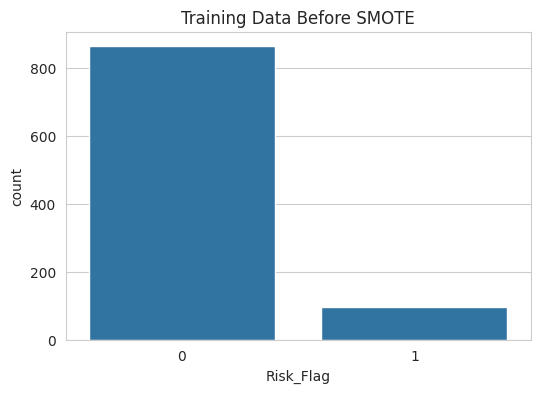

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=y_train
)

plt.title(
    "Training Data Before SMOTE"
)

plt.show()

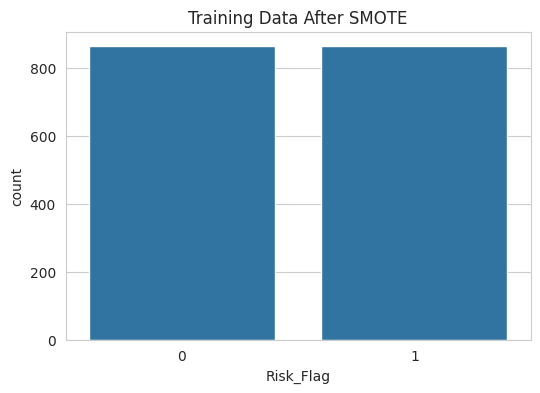

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=y_train_smote
)

plt.title(
    "Training Data After SMOTE"
)

plt.show()

In [30]:
pd.DataFrame(
    X_train_smote
).to_csv(
    "X_train_smote.csv",
    index=False
)


pd.DataFrame(
    X_test_scaled
).to_csv(
    "X_test_scaled.csv",
    index=False
)


y_train_smote.to_csv(
    "y_train_smote.csv",
    index=False
)


y_test.to_csv(
    "y_test.csv",
    index=False
)


print("Saved successfully")

Saved successfully
